# 06. LangGraph 도구(Tool) 사용 에이전트

---

## 실습 목표

LangGraph로 **도구를 직접 호출하는 에이전트**를 직접 구현한다.  
핵심 목표는 다음과 같다.
1. `@tool`로 Python 함수를 LLM 도구로 변환한다.
2. `llm.bind_tools(tools)`로 LLM에 도구 목록을 바인딩한다.
3. `tools_condition`으로 도구 호출 여부에 따라 분기한다.
4. `LLM → Tool → LLM`으로 이어지는 ReAct 형태의 실행 루프를 이해한다.

---

## ReAct 패턴이란?

**ReAct**는 **Re**asoning + **Act**ing — LLM이 생각하고 행동하는 반복 루프를 의미한다.
LLM이 바로 답할 수 있으면 답변을 생성하고, 외부 기능이 필요하면 도구를 호출한 뒤 그 결과를 다시 읽고 최종 답변을 생성한다.

```text
START
  ↓
[LLM 노드]
  ├─ 도구 호출 없음 → END
  │
  └─ 도구 호출 있음
        ↓
     [Tool 노드]
        ↓
     [LLM 노드로 복귀]
```
- LangGraph에서는 이 흐름을 명시적인 노드와 엣지로 구성한다.  
---

## 핵심 컴포넌트

| 컴포넌트 | 역할 |
|---|---|
| `@tool` | Python 함수를 LLM이 호출할 수 있는 도구로 변환한다. |
| `llm.bind_tools(tools)` | LLM에 사용 가능한 도구 목록을 전달한다. |
| `ToolNode` | AIMessage 안의 tool_calls를 읽고 실제 도구를 실행한다. |
| `tools_condition` | 마지막 AIMessage에 도구 호출이 있는지 판단해 다음 경로를 결정한다. |
| `MessagesState` | 사용자 메시지, AI 응답, 도구 결과를 messages에 누적한다. |

---

## 0. 환경 준비

이 실습은 OpenAI 모델을 사용하므로 `OPENAI_API_KEY`가 필요하다.  
`.env` 파일은 노트북 기준 상위 폴더(`../.env`)에 둔다.

예시:

```text
OPENAI_API_KEY=sk-...
```


In [1]:
from dotenv import load_dotenv
load_dotenv(override=True, dotenv_path="../.env")

True

## LLM 객체 생성

In [1]:
from langchain_openai import ChatOpenAI
from langchain.tools import tool
from langchain.messages import HumanMessage
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Image, display

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
print("준비 완료")

준비 완료


## 그래프 출력 함수

In [2]:
def show_graph(graph):
    """LangGraph 그래프를 시각화한다.

    Mermaid PNG 생성에 실패하면 ASCII 그래프로 대체한다.
    실습 환경에 따라 Mermaid 이미지 생성이 실패할 수 있으므로 예외 처리를 둔다.
    """
    try:
        display(Image(graph.get_graph().draw_mermaid_png()))
    except Exception as e:
        print(f"Mermaid 이미지 생성 실패: {e}")
        try:
            print(graph.get_graph().draw_ascii())
        except Exception as ascii_error:
            print(f"ASCII 그래프 생성 실패: {ascii_error}")


---

## 1. 도구(Tool) 정의

`@tool` 데코레이터는 일반 Python 함수를 LLM이 호출할 수 있는 도구로 변환한다.
도구의 이름, 입력 인자, 반환값, docstring은 LLM이 도구를 선택할 때 중요한 정보가 된다.

특히 **docstring**은 "이 도구가 언제 필요한지"를 알려주는 설명서 역할을 한다.

In [3]:
@tool
def add(a: float, b: float) -> float:
    """두 수를 더한다.

    Args:
        a: 첫 번째 수
        b: 두 번째 수
    """
    result = a + b
    print(f"  [도구 실행] add({a}, {b}) = {result}")
    return result


@tool
def multiply(a: float, b: float) -> float:
    """두 수를 곱한다.

    Args:
        a: 첫 번째 수
        b: 두 번째 수
    """
    result = a * b
    print(f"  [도구 실행] multiply({a}, {b}) = {result}")
    return result


@tool
def get_weather(city: str) -> str:
    """특정 도시의 현재 날씨 정보를 반환한다.

    Args:
        city: 날씨를 조회할 도시 이름
    """
    # 실제 서비스에서는 외부 날씨 API를 호출한다.
    # 이 실습에서는 API Key 없이 실행할 수 있도록 더미 데이터를 사용한다.
    weather_db = {
        "서울": "맑음, 22°C",
        "부산": "구름 많음, 25°C",
        "제주": "흐림, 20°C",
    }

    result = weather_db.get(city, f"{city}: 정보 없음")
    print(f"  [도구 실행] get_weather('{city}') = {result}")
    return result


# Agent가 사용할 도구 목록을 정의한다.
tools = [add, multiply, get_weather]

print("[등록된 도구]")
for t in tools:
    print(f"- {t.name}: {t.description}")


[등록된 도구]
- add: 두 수를 더한다.

    Args:
        a: 첫 번째 수
        b: 두 번째 수
- multiply: 두 수를 곱한다.

    Args:
        a: 첫 번째 수
        b: 두 번째 수
- get_weather: 특정 도시의 현재 날씨 정보를 반환한다.

    Args:
        city: 날씨를 조회할 도시 이름


### 도구 직접 실행 확인

LangGraph에 연결하기 전에 도구가 정상적으로 동작하는지 먼저 확인한다.  
`@tool`이 적용된 함수는 `.invoke()`로 직접 실행할 수 있다.

In [4]:
print(add.invoke({"a": 3, "b": 7}))
print(multiply.invoke({"a": 4, "b": 5}))
print(get_weather.invoke({"city": "서울"}))


  [도구 실행] add(3.0, 7.0) = 10.0
10.0
  [도구 실행] multiply(4.0, 5.0) = 20.0
20.0
  [도구 실행] get_weather('서울') = 맑음, 22°C
맑음, 22°C


---

## 2. LLM에 도구 바인딩
LLM은 Python 함수를 직접 실행하지 않는다.
`bind_tools()`는 LLM에게 "호출 가능한 도구 목록과 입력 스키마"를 알려준다.

이후 LLM은 답변을 바로 생성하거나, 필요한 경우 `tool_calls`가 포함된 `AIMessage`를 생성한다.

In [5]:
# LLM에 도구 목록을 바인딩한다.
# 이 모델은 필요할 때 add, multiply, get_weather 도구를 호출할 수 있다.
llm_with_tools = llm.bind_tools(tools)

# 도구 호출이 필요한 질문을 넣어 AIMessage의 tool_calls를 확인한다.
tool_call_response = llm_with_tools.invoke([
    HumanMessage(content="3 곱하기 7을 계산해줘")
])

print("[AIMessage 내용]")
print(tool_call_response.content)

print("\n[도구 호출 정보]")
print(tool_call_response.tool_calls)

[AIMessage 내용]


[도구 호출 정보]
[{'name': 'multiply', 'args': {'a': 3, 'b': 7}, 'id': 'call_3CqxsjB0qQS1INnouJ6fe8cB', 'type': 'tool_call'}]


위 실행에서 `content`가 비어 있고 `tool_calls`만 들어 있을 수 있다.  
이 경우 LLM은 최종 답변을 한 것이 아니라 “도구를 호출해야 한다”고 판단한 상태이다.

도구 실행은 다음 단계의 `ToolNode`가 담당한다.

---

## 3. ReAct 에이전트 그래프 구성

이제 LangGraph로 다음 구조를 만든다.

```text
START → llm
          ├─ tool_calls 있음 → tools → llm
          └─ tool_calls 없음 → END
```

핵심은 `llm` 노드와 `tools` 노드가 반복적으로 연결된다는 점이다.  
도구 호출 결과는 `ToolMessage`로 `messages`에 추가되고, LLM은 그 결과를 읽은 뒤 최종 답변을 생성한다.

In [6]:
def llm_node(state: MessagesState) -> dict:
    """LLM을 호출하는 노드이다.

    입력:
        state["messages"] 전체 대화 이력

    출력:
        새 AIMessage 1개

    LLM이 도구가 필요하다고 판단하면 AIMessage 안에 tool_calls가 포함된다.
    """
    response = llm_with_tools.invoke(state["messages"])

    # MessagesState는 messages 필드에 add_messages reducer를 적용한다.
    # 따라서 새 메시지만 리스트로 반환하면 기존 messages 뒤에 누적된다.
    return {"messages": [response]}


# ToolNode는 마지막 AIMessage의 tool_calls를 읽고 실제 도구를 실행한다.
# 실행 결과는 ToolMessage로 messages에 추가된다.
tool_node = ToolNode(tools)


# StateGraph는 MessagesState를 공유 상태로 사용한다.
builder = StateGraph(MessagesState)

# 노드를 등록한다.
builder.add_node("llm", llm_node)
builder.add_node("tools", tool_node)

# 시작 지점에서 LLM 노드로 이동한다.
builder.add_edge(START, "llm")

# LLM 응답에 도구 호출이 있으면 tools 노드로 이동하고,
# 도구 호출이 없으면 END로 종료한다.
# path_map을 명시하면 그래프 시각화에서 분기 대상이 더 명확하게 보인다.
builder.add_conditional_edges(
    "llm",
    tools_condition,
    {
        "tools": "tools",
        END: END,
    },
)

# 도구 실행이 끝나면 다시 LLM 노드로 돌아간다.
# LLM은 ToolMessage를 읽고 최종 답변을 생성한다.
builder.add_edge("tools", "llm")

# 그래프를 실행 가능한 객체로 컴파일한다.
agent = builder.compile()

show_graph(agent)


Mermaid 이미지 생성 실패: Failed to reach https://mermaid.ink API while trying to render your graph after 1 retries. To resolve this issue:
1. Check your internet connection and try again
2. Try with higher retry settings: `draw_mermaid_png(..., max_retries=5, retry_delay=2.0)`
3. Use the Pyppeteer rendering method which will render your graph locally in a browser: `draw_mermaid_png(..., draw_method=MermaidDrawMethod.PYPPETEER)`
        +-----------+       
        | __start__ |       
        +-----------+       
              *             
              *             
              *             
          +-----+           
          | llm |           
          +-----+.          
          .       .         
        ..         ..       
       .             .      
+---------+       +-------+ 
| __end__ |       | tools | 
+---------+       +-------+ 


---

## 4. 에이전트 실행 테스트

`invoke()`는 그래프를 끝까지 실행한 뒤 최종 State를 반환한다.  
최종 답변은 보통 `result["messages"][-1].content`에서 확인한다.

In [8]:
print("=== 테스트 1: 계산 도구 사용 ===")

result = agent.invoke({
    "messages": [
        HumanMessage(content="3 곱하기 7을 계산하고, 거기에 15를 더해줘")
    ]
})

print("\n[전체 메시지 수]", len(result["messages"]))
print("\n[최종 답변]")
print(result["messages"][-1].content)

=== 테스트 1: 계산 도구 사용 ===
  [도구 실행] multiply(3.0, 7.0) = 21.0  [도구 실행] add(15.0, 0.0) = 15.0

  [도구 실행] add(21.0, 15.0) = 36.0

[전체 메시지 수] 7

[최종 답변]
3 곱하기 7은 21이고, 여기에 15를 더하면 36입니다.


In [9]:
print("=== 테스트 2: 날씨 도구 사용 ===")

result = agent.invoke({
    "messages": [
        HumanMessage(content="서울과 부산의 날씨를 알려줘")
    ]
})

print("\n[전체 메시지 수]", len(result["messages"]))
print("\n[최종 답변]")
print(result["messages"][-1].content)


=== 테스트 2: 날씨 도구 사용 ===
  [도구 실행] get_weather('서울') = 맑음, 22°C
  [도구 실행] get_weather('부산') = 구름 많음, 25°C

[전체 메시지 수] 5

[최종 답변]
현재 서울의 날씨는 맑고 기온은 22°C입니다. 부산은 구름이 많고 기온은 25°C입니다.


### 메시지 구조 확인

Tool Agent의 실행 결과에는 사용자 메시지, AI의 도구 호출 메시지, 도구 실행 결과, 최종 AI 답변이 함께 들어 있다.  
이 구조를 확인하면 ReAct 루프를 이해하기 쉽다.

In [11]:
from langchain.messages import AIMessage


result = agent.invoke({
    "messages": [
        HumanMessage(content="5 더하기 8은 얼마야?")
    ]
})

for i, msg in enumerate(result["messages"], start=1):
    print(f"\n[{i}] {msg.__class__.__name__}")

    if isinstance(msg, AIMessage) and msg.tool_calls:
        print("도구 호출:", msg.tool_calls)
    else:
        print("내용:", msg.content)

  [도구 실행] add(5.0, 8.0) = 13.0

[1] HumanMessage
내용: 5 더하기 8은 얼마야?

[2] AIMessage
도구 호출: [{'name': 'add', 'args': {'a': 5, 'b': 8}, 'id': 'call_szQEvqUvtZ3GJFdUPE6m7dLz', 'type': 'tool_call'}]

[3] ToolMessage
내용: 13.0

[4] AIMessage
내용: 5 더하기 8은 13입니다.


---

## 5. stream()으로 실행 과정 추적

`stream()`은 그래프가 실행되는 중간 결과를 단계별로 확인할 때 사용한다.  
여기서는 `stream_mode="updates"`를 사용해 각 노드가 반환한 업데이트만 출력한다.


In [12]:
from langchain.messages import ToolMessage


print("=== stream()으로 에이전트 실행 추적 ===")
print(f"{'노드':<10} {'메시지 타입':<22} {'내용 요약':<45}")
print("-" * 85)

for event in agent.stream(
    {"messages": [HumanMessage(content="5 더하기 8은 얼마야?")]},
    stream_mode="updates",
):
    # event는 한 단계에서 실행된 노드명과 해당 노드의 출력으로 구성된다.
    for node_name, output in event.items():
        msgs = output.get("messages", [])

        for msg in msgs:
            if isinstance(msg, AIMessage):
                if msg.tool_calls:
                    for tool_call in msg.tool_calls:
                        summary = f"{tool_call['name']}({tool_call['args']})"
                        print(f"{node_name:<10} {'AIMessage(도구 요청)':<22} {summary:<45}")
                else:
                    summary = (msg.content or "")[:40]
                    print(f"{node_name:<10} {'AIMessage(최종 답변)':<22} {summary:<45}")

            elif isinstance(msg, ToolMessage):
                summary = f"{msg.name} → {str(msg.content)[:35]}"
                print(f"{node_name:<10} {'ToolMessage(도구 결과)':<22} {summary:<45}")


=== stream()으로 에이전트 실행 추적 ===
노드         메시지 타입                 내용 요약                                        
-------------------------------------------------------------------------------------
llm        AIMessage(도구 요청)       add({'a': 5, 'b': 8})                        
  [도구 실행] add(5.0, 8.0) = 13.0
tools      ToolMessage(도구 결과)     add → 13.0                                   
llm        AIMessage(최종 답변)       5 더하기 8은 13입니다.                              


---

## 6. 현재 권장되는 고수준 Agent 방식과 비교

LangGraph로 직접 구현하면 노드와 엣지를 세밀하게 제어할 수 있다.  
반면 LangChain v1에서는 `create_agent`를 사용해 도구 호출 Agent를 더 간단히 만들 수 있다.

과거에는 `langgraph.prebuilt.create_react_agent`가 자주 사용되었으나, 현재 LangChain v1 기준에서는 `langchain.agents.create_agent` 사용이 권장된다.  
따라서 이 실습에서는 `create_react_agent`를 사용하지 않는다.

In [13]:
# 이 셀은 LangChain v1 환경에서만 실행된다.
# 현재 권장되는 고수준 Agent 생성 방식이다.
from langchain.agents import create_agent
try:

    high_level_agent = create_agent(
        model=llm,
        tools=tools,
        system_prompt="너는 계산과 날씨 조회를 정확하게 수행하는 AI 도우미이다.",
    )

    high_level_result = high_level_agent.invoke({
        "messages": [
            {"role": "user", "content": "제주 날씨 알려줘"}
        ]
    })

    print("[create_agent 결과]")
    print(high_level_result["messages"][-1].content)

except Exception as e:
    print("create_agent 실행을 건너뛴다.")
    print(f"원인: {e}")


  [도구 실행] get_weather('제주') = 흐림, 20°C
[create_agent 결과]
현재 제주 날씨는 흐림이며, 기온은 20°C입니다.


### 직접 구현과 고수준 Agent의 차이

| 방식 | 장점 | 한계 |
|---|---|---|
| LangGraph 직접 구현 | 노드, 엣지, 조건 분기, 상태를 직접 제어할 수 있다. | 코드가 길어진다. |
| LangChain `create_agent` | 짧은 코드로 도구 호출 Agent를 만들 수 있다. | 그래프 구조를 세밀하게 수정하기 어렵다. |

초보자 실습에서는 LangGraph 직접 구현이 더 적합하다.  
Agent의 내부 구조인 `LLM → Tool → LLM` 루프를 눈으로 확인할 수 있기 때문이다.

---

## 7. 커스텀 시스템 프롬프트 추가

직접 구현 방식의 장점은 LLM 노드를 원하는 방식으로 수정할 수 있다는 점이다.  
아래 예제는 LLM 호출 직전에 `SystemMessage`를 추가한다.

주의할 점은 `SystemMessage`를 State에 계속 누적하지 않는 것이다.  
매 호출 시점에만 앞에 붙여서 LLM에 전달한다.

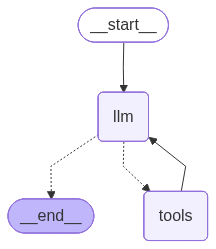

In [16]:
from langchain.messages import SystemMessage


AGENT_SYSTEM = """너는 수학·날씨 도구를 정확하게 사용하는 AI 도우미이다.
- 계산이 필요하면 반드시 계산 도구를 사용한다.
- 날씨 질문은 반드시 날씨 도구를 사용한다.
- 최종 답변은 한국어로 간결하게 작성한다.
"""


def custom_llm_node(state: MessagesState) -> dict:
    """시스템 프롬프트를 추가한 LLM 노드이다.

    SystemMessage는 LLM 호출에만 사용한다.
    State에는 AIMessage만 반환하여 시스템 프롬프트가 반복 누적되지 않게 한다.
    """
    messages = [SystemMessage(content=AGENT_SYSTEM)] + state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}


custom_builder = StateGraph(MessagesState)
custom_builder.add_node("llm", custom_llm_node)
custom_builder.add_node("tools", tool_node)

custom_builder.add_edge(START, "llm")
custom_builder.add_conditional_edges(
    "llm",
    tools_condition,
    {
        "tools": "tools",
        END: END,
    },
)
custom_builder.add_edge("tools", "llm")

custom_agent = custom_builder.compile()

show_graph(custom_agent)


In [19]:
result = custom_agent.invoke({
    "messages": [
        HumanMessage(content="12 곱하기 8이 얼마인지 계산해줘")
    ]
})

print(result["messages"][-1].content)


  [도구 실행] multiply(12.0, 8.0) = 96.0
12 곱하기 8은 96입니다.


---

## 정리

Tool Agent의 기본 패턴은 다음과 같다.

```python
# 1. 도구 정의
@tool
def my_tool(input: str) -> str:
    """도구 설명을 작성한다."""
    return result

# 2. LLM에 도구 바인딩
llm_with_tools = llm.bind_tools([my_tool])

# 3. LLM 노드 정의
def llm_node(state: MessagesState) -> dict:
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

# 4. ToolNode 정의
tool_node = ToolNode([my_tool])

# 5. 그래프 구성
builder = StateGraph(MessagesState)
builder.add_node("llm", llm_node)
builder.add_node("tools", tool_node)

builder.add_edge(START, "llm")
builder.add_conditional_edges(
    "llm",
    tools_condition,
    {
        "tools": "tools",
        END: END,
    },
)
builder.add_edge("tools", "llm")

agent = builder.compile()
```

핵심은 다음과 같다.

| 개념 | 설명 |
|---|---|
| `@tool` | Python 함수를 LLM이 호출 가능한 도구로 바꾼다. |
| `bind_tools()` | LLM에게 사용 가능한 도구 목록을 알려준다. |
| `AIMessage.tool_calls` | LLM이 요청한 도구 호출 정보이다. |
| `ToolNode` | `tool_calls`를 실제 Python 함수 실행으로 바꾼다. |
| `ToolMessage` | 도구 실행 결과를 LLM에게 전달하는 메시지이다. |
| `tools_condition` | 도구 호출 여부에 따라 `tools` 또는 `END`로 분기한다. |
| `MessagesState` | 사용자 메시지, AIMessage, ToolMessage를 누적한다. |

LangGraph 직접 구현 방식은 Agent의 내부 동작을 학습하기에 적합하다.  
상용 서비스나 빠른 프로토타입에서는 LangChain의 `create_agent`를 함께 검토할 수 있다.
